# 02_analysis — Segmentation & Profil d'effort

## Objectif
- Segmenter la trace en **étapes officielles GR65** (Le Puy → Saint-Jean-Pied-de-Port)
- Proposer une **variante intelligente** par distance cible (km/jour) entre point où un hébergement est présent
- Calculer un **score d'effort composite** (D+ normalisé + distance normalisée) par étape
- Exporter un CSV par étape pour la Phase 3 (POI & hébergements)

## Entrée
- `data_raw/profile_srtm.csv` — 14 765 points, colonnes : lat, lon, time, elevation, distance_m, elevation_diff, slope, place_name

## Sorties
- `data_raw/etapes_officielles.csv` — 1 ligne par étape officielle
- `data_raw/etapes_custom.csv` — 1 ligne par étape personnalisée

> **Run All autorisé** sur ce notebook.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

# Chemins
PROFILE_CSV  = "C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw/profile_srtm.csv"
OUT_OFFICIEL = "C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw/etapes_officielles.csv"
OUT_CUSTOM   = "C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw/etapes_custom.csv"

df = pd.read_csv(PROFILE_CSV)
df["elevation_diff"] = pd.to_numeric(df["elevation_diff"], errors="coerce").fillna(0)

TOTAL_KM = df["distance_m"].max() / 1000
print(f"Points chargés  : {len(df):,}")
print(f"Distance totale : {TOTAL_KM:.1f} km")
df.head(3)

Points chargés  : 14,765
Distance totale : 744.6 km


,lon,lat,time,elevation,distance_m,place_name,elevation_diff,slope
0,3.88478,45.04559,NaN,680.0,0.000000,Le Puy-en-Velay,0.0,NaN
1,3.88396,45.04557,NaN,662.0,64.460946,Le Puy-en-Velay,-18.0,-0.279239
2,3.88319,45.04553,NaN,652.0,125.118634,Le Puy-en-Velay,-10.0,-0.164860


## 1. Étapes officielles GR65
33 étapes de référence du guide officiel FFRandonnée.  
Le découpage est basé sur la **distance cumulée** : chaque ville-étape est associée à son km de départ sur le tracé.

In [11]:
# Étapes officielles GR65 — (nom, distance_départ_km)
# Source : guide FFRandonnée / Miam Miam Dodo
ETAPES_OFFICIELLES = [
    ("Le Puy-en-Velay",           0),
    ("Saint-Privat-d'Allier",    24),
    ("Saugues",                   43),
    ("Saint-Alban-sur-Limagnole", 67),
    ("Aumont-Aubrac",             90),
    ("Nasbinals",                112),
    ("Saint-Chély-d'Aubrac",     128),
    ("Saint-Côme-d'Olt",         142),
    ("Espalion",                  149),
    ("Estaing",                   162),
    ("Golinhac",                  178),
    ("Conques",                   197),
    ("Decazeville",               218),
    ("Figeac",                    243),
    ("Cajarc",                    271),
    ("Limogne-en-Quercy",         292),
    ("Cahors",                    321),
    ("Lauzerte",                  361),
    ("Moissac",                   397),
    ("Auvillar",                  414),
    ("Lectoure",                  444),
    ("Condom",                    468),
    ("Éauze",                     496),
    ("Nogaro",                    516),
    ("Aire-sur-l'Adour",          539),
    ("Miramont-Sensacq",          561),
    ("Arzacq-Arraziguet",         583),
    ("Arthez-de-Béarn",           606),
    ("Navarrenx",                 634),
    ("Aroue",                     654),
    ("Saint-Palais",              667),
    ("Ostabat-Asmé",              695),
    ("Saint-Jean-Pied-de-Port",   740),
]

print(f"{len(ETAPES_OFFICIELLES)} étapes officielles chargées")

33 étapes officielles chargées


In [12]:
def compute_etape_stats(df, bornes_km):
    """
    Calcule les statistiques pour chaque étape définie par une liste de km de départ.
    bornes_km : liste de (nom, km_depart)
    Retourne un DataFrame avec 1 ligne par étape.
    """
    records = []
    for i, (nom, km_start) in enumerate(bornes_km):
        km_end = bornes_km[i + 1][1] if i + 1 < len(bornes_km) else df["distance_m"].max() / 1000

        mask = (df["distance_m"] / 1000 >= km_start) & (df["distance_m"] / 1000 < km_end)
        seg  = df[mask]

        if seg.empty:
            continue

        distance_km = km_end - km_start
        d_plus      = seg[seg["elevation_diff"] > 0]["elevation_diff"].sum()
        d_minus     = seg[seg["elevation_diff"] < 0]["elevation_diff"].sum()
        alt_min     = seg["elevation"].min()
        alt_max     = seg["elevation"].max()
        pente_moy   = seg["slope"].abs().median() * 100  # en %

        records.append({
            "etape"       : i + 1,
            "depart"      : nom,
            "arrivee"     : bornes_km[i + 1][0] if i + 1 < len(bornes_km) else "Arrivée",
            "distance_km" : round(distance_km, 1),
            "d_plus_m"    : round(d_plus, 0),
            "d_minus_m"   : round(abs(d_minus), 0),
            "alt_min_m"   : round(alt_min, 0),
            "alt_max_m"   : round(alt_max, 0),
            "pente_moy_pct": round(pente_moy, 1),
            "km_start"    : km_start,
            "km_end"      : km_end,
        })

    result = pd.DataFrame(records)

    # Score d'effort composite : D+ normalisé (60%) + distance normalisée (40%)
    result["score_effort"] = (
        0.6 * (result["d_plus_m"]    / result["d_plus_m"].max()) +
        0.4 * (result["distance_km"] / result["distance_km"].max())
    ).round(3)

    # Niveau de difficulté lisible
    q33 = result["score_effort"].quantile(0.33)
    q66 = result["score_effort"].quantile(0.66)
    result["difficulte"] = pd.cut(
        result["score_effort"],
        bins=[-np.inf, q33, q66, np.inf],
        labels=["Facile", "Modéré", "Difficile"]
    )

    return result


df_officielles = compute_etape_stats(df, ETAPES_OFFICIELLES)
df_officielles

,etape,depart,arrivee,distance_km,d_plus_m,d_minus_m,alt_min_m,alt_max_m,pente_moy_pct,km_start,km_end,score_effort,difficulte
0,1,Le Puy-en-Velay,Saint-Privat-d'Allier,24.0,872.0,679.0,640.0,1214.0,2.3,0,24.000000,0.510,Difficile
1,2,Saint-Privat-d'Allier,Saugues,19.0,1138.0,1065.0,595.0,1102.0,2.8,24,43.000000,0.556,Difficile
2,3,Saugues,Saint-Alban-sur-Limagnole,24.0,954.0,669.0,928.0,1332.0,2.1,43,67.000000,0.538,Difficile
3,4,Saint-Alban-sur-Limagnole,Aumont-Aubrac,23.0,771.0,949.0,920.0,1230.0,2.1,67,90.000000,0.467,Modéré
4,5,Aumont-Aubrac,Nasbinals,22.0,572.0,474.0,1016.0,1255.0,2.2,90,112.000000,0.390,Modéré
5,6,Nasbinals,Saint-Chély-d'Aubrac,16.0,579.0,539.0,1150.0,1370.0,1.7,112,128.000000,0.339,Facile
6,7,Saint-Chély-d'Aubrac,Saint-Côme-d'Olt,14.0,653.0,1163.0,681.0,1201.0,1.8,128,142.000000,0.346,Facile
7,8,Saint-Côme-d'Olt,Espalion,7.0,290.0,606.0,365.0,688.0,0.0,142,149.000000,0.161,Facile
8,9,Espalion,Estaing,13.0,693.0,575.0,331.0,520.0,2.0,149,162.000000,0.351,Modéré
9,10,Estaing,Golinhac,16.0,940.0,819.0,313.0,658.0,0.0,162,178.000000,0.462,Modéré


## 2. Segmentation intelligente (Hébergements réels)
Modifiez `KM_PAR_JOUR` selon votre rythme tout enveillant à relier des points où au moins un hébergement est présent.

In [13]:
# 1. Charger les hébergements collectés au notebook 01
HEBERGS_CSV = "C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw/hebergements.csv"
df_h = pd.read_csv(HEBERGS_CSV)

# 2. Paramètre de distance cible (Renommé pour correspondre à l'export)
KM_PAR_JOUR = 25 
total_km = df["distance_m"].max() / 1000

# 3. Algorithme de recherche des villes-étapes
bornes_km_custom = [("Le Puy-en-Velay", 0)]
current_km = 0

while current_km < total_km - (KM_PAR_JOUR / 2):
    target_km = current_km + KM_PAR_JOUR
    
    if target_km >= total_km:
        break
        
    options = df_h[df_h["km_sur_trace"] > current_km + 5]
    
    if options.empty:
        break
        
    idx_closest = (options["km_sur_trace"] - target_km).abs().idxmin()
    heb_closest = options.loc[idx_closest]
    
    bornes_km_custom.append((heb_closest["nom"], heb_closest["km_sur_trace"]))
    current_km = heb_closest["km_sur_trace"]

# 4. Calcul des statistiques
df_custom = compute_etape_stats(df, bornes_km_custom)


## 3. Visualisation — Profil d'effort par étape officielle

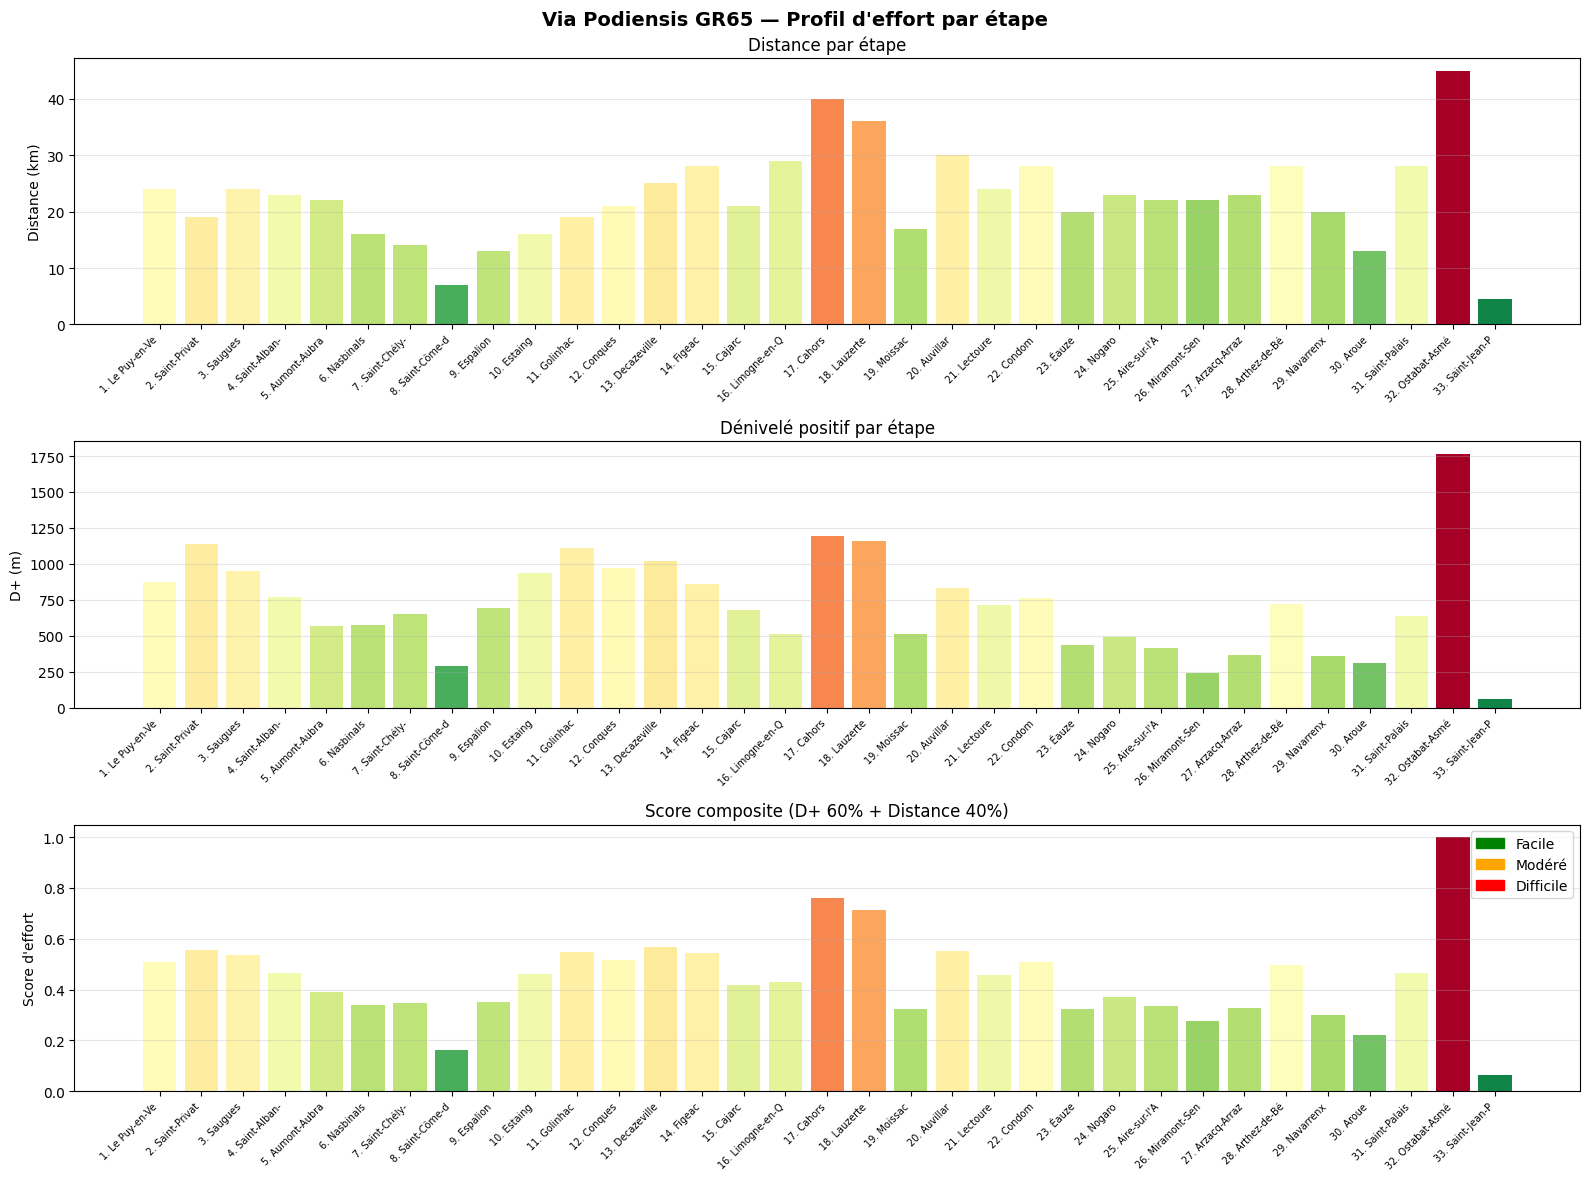

Graphique exporté : data_raw/profil_effort.png


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle("Via Podiensis GR65 — Profil d'effort par étape", fontsize=14, fontweight="bold")

colors = cm.RdYlGn_r(df_officielles["score_effort"] / df_officielles["score_effort"].max())
x = range(len(df_officielles))
labels = [f"{r.etape}. {r.depart[:12]}" for r in df_officielles.itertuples()]

# Distance par étape
axes[0].bar(x, df_officielles["distance_km"], color=colors)
axes[0].set_ylabel("Distance (km)")
axes[0].set_title("Distance par étape")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
axes[0].grid(axis="y", alpha=0.3)

# Dénivelé positif
axes[1].bar(x, df_officielles["d_plus_m"], color=colors)
axes[1].set_ylabel("D+ (m)")
axes[1].set_title("Dénivelé positif par étape")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
axes[1].grid(axis="y", alpha=0.3)

# Score d'effort composite
bars = axes[2].bar(x, df_officielles["score_effort"], color=colors)
axes[2].set_ylabel("Score d'effort")
axes[2].set_title("Score composite (D+ 60% + Distance 40%)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
axes[2].grid(axis="y", alpha=0.3)

# Légende difficulté
from matplotlib.patches import Patch
legend = [
    Patch(color="green",  label="Facile"),
    Patch(color="orange", label="Modéré"),
    Patch(color="red",    label="Difficile"),
]
axes[2].legend(handles=legend, loc="upper right")

plt.tight_layout()
os.makedirs("../../data_raw", exist_ok=True)
plt.savefig("../../data_raw/profil_effort.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique exporté : data_raw/profil_effort.png")

## 4. Profil altimétrique annoté

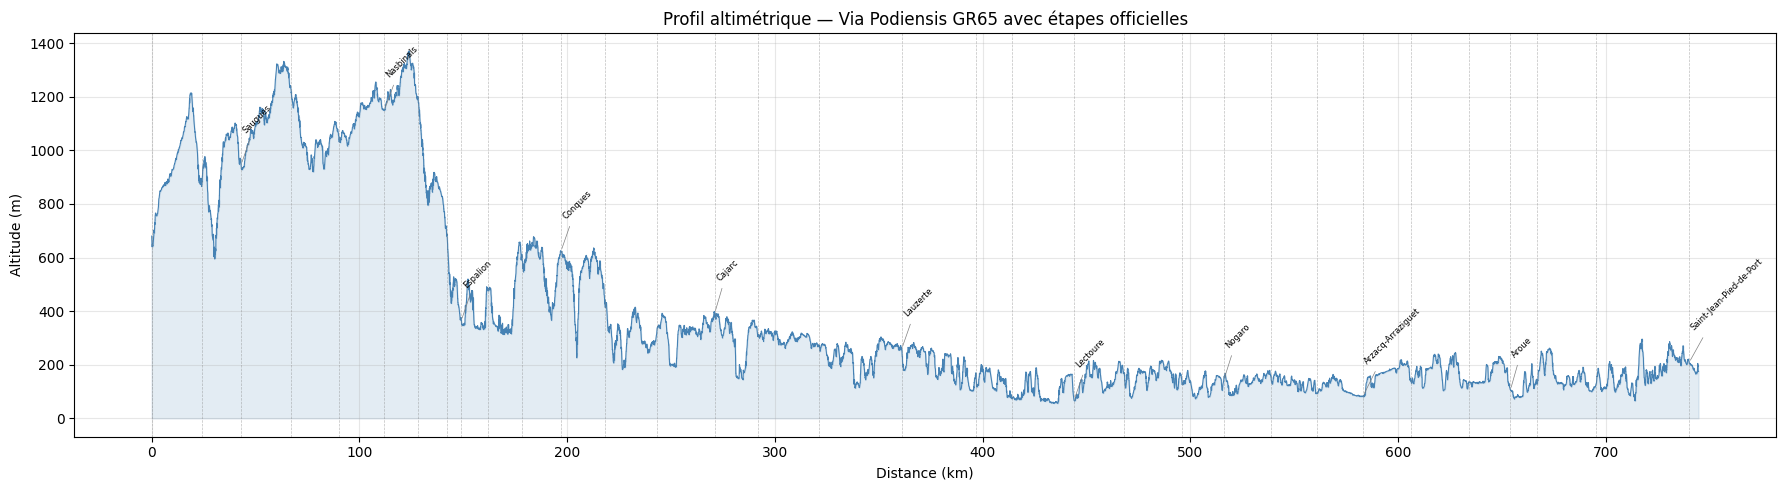

Graphique exporté : data_raw/profil_altimetrique.png


In [15]:
fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(df["distance_m"] / 1000, df["elevation"], color="steelblue", linewidth=0.8)
ax.fill_between(df["distance_m"] / 1000, df["elevation"], alpha=0.15, color="steelblue")

# Annoter les villes-étapes officielles
for _, row in df_officielles.iterrows():
    km = row["km_start"]
    # Trouver l'altitude au point le plus proche
    idx = (df["distance_m"] / 1000 - km).abs().idxmin()
    alt = df.loc[idx, "elevation"]
    ax.axvline(km, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
    if row["etape"] % 3 == 0:  # annoter 1 étape sur 3 pour lisibilité
        ax.annotate(
            row["depart"],
            xy=(km, alt),
            xytext=(km, alt + 120),
            fontsize=6,
            rotation=45,
            ha="left",
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
        )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Altitude (m)")
ax.set_title("Profil altimétrique — Via Podiensis GR65 avec étapes officielles")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../../data_raw/profil_altimetrique.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique exporté : data_raw/profil_altimetrique.png")

## 5. Résumé statistique

In [16]:
print("=" * 50)
print("VIA PODIENSIS GR65 — Résumé général")
print("=" * 50)
print(f"Distance totale    : {TOTAL_KM:.1f} km")
print(f"D+ total           : {df_officielles['d_plus_m'].sum():,.0f} m")
print(f"D- total           : {df_officielles['d_minus_m'].sum():,.0f} m")
print(f"Nb étapes          : {len(df_officielles)}")
print(f"Distance moy/étape : {df_officielles['distance_km'].mean():.1f} km")
print(f"D+ moyen/étape     : {df_officielles['d_plus_m'].mean():.0f} m")
print()
print("Étapes les plus difficiles :")
print(df_officielles.nlargest(5, "score_effort")[["etape", "depart", "arrivee", "distance_km", "d_plus_m", "score_effort", "difficulte"]].to_string(index=False))
print()
print("Étapes les plus faciles :")
print(df_officielles.nsmallest(5, "score_effort")[["etape", "depart", "arrivee", "distance_km", "d_plus_m", "score_effort", "difficulte"]].to_string(index=False))

VIA PODIENSIS GR65 — Résumé général
Distance totale    : 744.6 km
D+ total           : 23,611 m
D- total           : 24,116 m
Nb étapes          : 33
Distance moy/étape : 22.6 km
D+ moyen/étape     : 715 m

Étapes les plus difficiles :
 etape                depart                 arrivee  distance_km  d_plus_m  score_effort difficulte
    32          Ostabat-Asmé Saint-Jean-Pied-de-Port         45.0    1765.0         1.000  Difficile
    17                Cahors                Lauzerte         40.0    1192.0         0.761  Difficile
    18              Lauzerte                 Moissac         36.0    1160.0         0.714  Difficile
    13           Decazeville                  Figeac         25.0    1017.0         0.568  Difficile
     2 Saint-Privat-d'Allier                 Saugues         19.0    1138.0         0.556  Difficile

Étapes les plus faciles :
 etape                  depart           arrivee  distance_km  d_plus_m  score_effort difficulte
    33 Saint-Jean-Pied-de-Port    

## 6. Export

In [17]:
df_officielles.to_csv(OUT_OFFICIEL, index=False)
df_custom.to_csv(OUT_CUSTOM, index=False)

print(f"Exporté : {OUT_OFFICIEL} ({len(df_officielles)} étapes)")
print(f"Exporté : {OUT_CUSTOM} ({len(df_custom)} étapes @ {KM_PAR_JOUR} km/j)")

Exporté : C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw/etapes_officielles.csv (33 étapes)
Exporté : C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw/etapes_custom.csv (30 étapes @ 25 km/j)
